In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_idx=pd.read_csv('economic_index.csv')

In [4]:
df_idx.head(2)

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394


## Drop Unneccesary

In [5]:
df_idx.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [6]:
df_idx.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
#cheack null values
df_idx.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

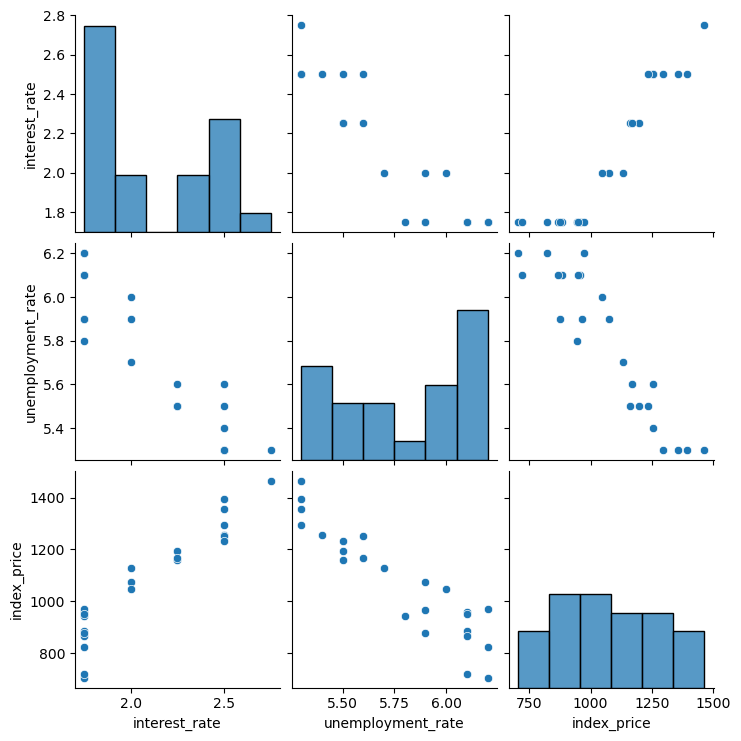

In [8]:
#visualization
sns.pairplot(df_idx)
plt.show()


In [9]:
df_idx.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


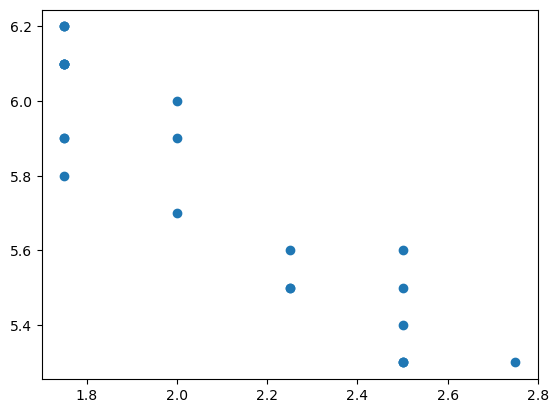

In [10]:
#Visualize the datapoint 
plt.scatter(df_idx['interest_rate'],df_idx['unemployment_rate'])
plt.show()

In [11]:
X=df_idx.iloc[:,:-1]
y=df_idx.iloc[:,-1]


In [12]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [13]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,Y_train,Y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [15]:
x_train.shape

(18, 2)

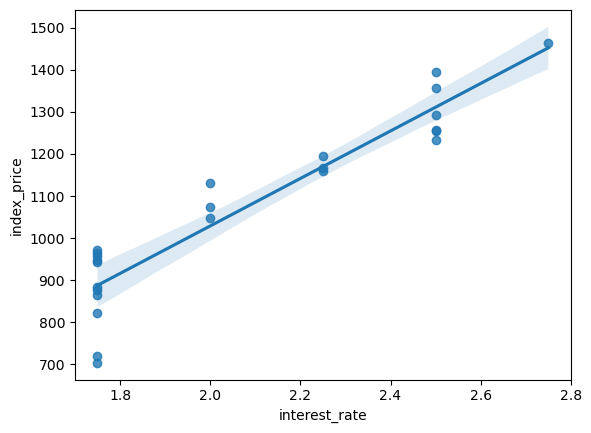

In [16]:
sns.regplot(x=df_idx['interest_rate'],y=df_idx['index_price'])
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()


In [18]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [19]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [20]:
from sklearn.linear_model import LinearRegression
Regression =LinearRegression()


In [21]:
Regression.fit(x_train,Y_train)

LinearRegression()

In [22]:
from sklearn.model_selection import cross_val_score
val_score=cross_val_score(Regression,x_train,Y_train, scoring='neg_mean_absolute_error',cv=5)

In [23]:
mean_vel=np.mean(val_score)

In [24]:
val_score


array([-35.61778846, -78.17705882, -82.41929311, -73.74953633,
       -24.64102564])

In [25]:
mean_vel

np.float64(-58.92094047300401)

In [26]:
Y_pred = Regression.predict(x_test)
Y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [28]:
mse = mean_squared_error(Y_test,Y_pred)
mae =mean_absolute_error(Y_test,Y_pred)
rmse = np.sqrt(mse)

In [29]:
print(f'MSE: {mse}\nMAE: {mae},\nRMSE: {rmse}')

MSE: 8108.567426306604
MAE: 73.80444932337097,
RMSE: 90.04758423359621


In [30]:
from sklearn.metrics import r2_score

In [31]:
score = r2_score(Y_test,Y_pred)

In [32]:
1-(1-score)*(len(Y_test))/(len(y_test)-x_test.shape[1]-1)

NameError: name 'y_test' is not defined

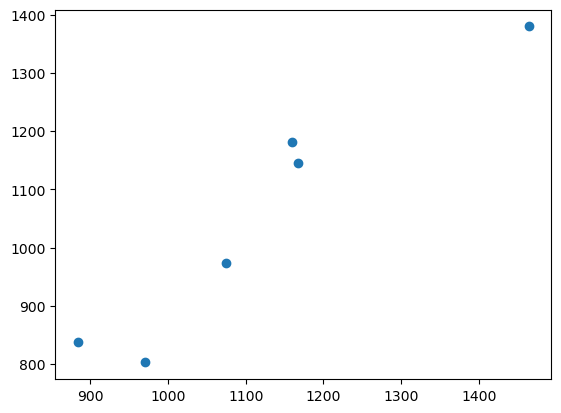

In [ ]:
plt.scatter(Y_test,Y_pred)
plt.show()

In [ ]:
Residual = Y_test - Y_pred

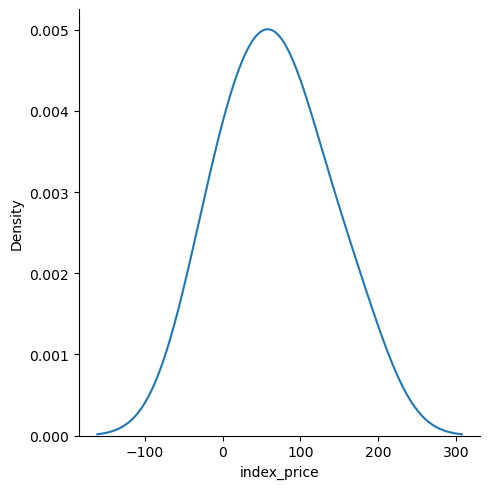

In [ ]:
sns.displot(Residual,kind='kde')
plt.show()

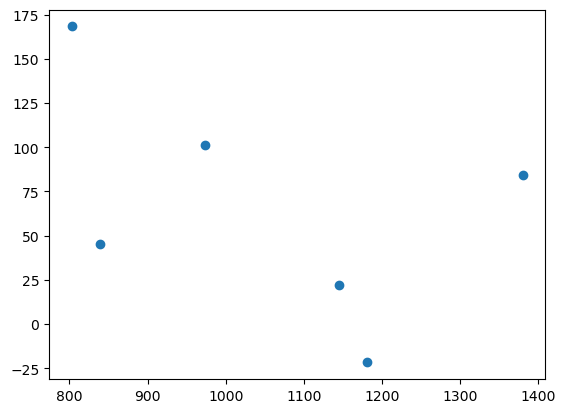

In [ ]:
plt.scatter(Y_pred,Residual)
plt.show()

In [ ]:
import statsmodels.api as sm


In [ ]:
models = sm.OLS(Y_train,x_train).fit()
print(models.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sat, 04 Oct 2025   Prob (F-statistic):                       0.754
Time:                        14:01:22   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

D:\test\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
Regression.coef_

array([  88.27275507, -116.25716066])